<a href="https://colab.research.google.com/github/Chi254/P1_personal-loan-modeling/blob/main/01_eda_personal_loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


This notebook focuses on **Exploratory Data Analysis (EDA).**
 Objective
- Understand dataset.
- Identify and deal with (potential) data quality issues.
- Assess  the relationships
between customer characteristics (features) and personal loan acceptance (target)
before building predictive models.


# Dataset Overview

## Dataset Description

The dataset contains 5000 rows of customer-level information, divide to 14 columns
including demographic, financial, and banking-related
attributes.

## Target Variable

The target variable is `Personal Loan`.

- 1: Customer accepts the personal loan.
- 0: Customer does not accept the personal loan.

1. LOAD DATA

In [1]:
# Importing the necessary libraries
import math
import numpy                            as np                        # importing numpy library
import pandas                           as pd                        # importing pandas library
import seaborn                          as sns                       # For Data Visualization
import matplotlib.pyplot                as plt                       # Necessary module for plotting purpose
import warnings                                                      # importing warning library

# add graphs into jupiter notebook
%matplotlib inline
warnings.filterwarnings('ignore')                                    # for ignoring warnings in notebook

import statsmodels.api                  as sm                        # importing statsmodel api
from sklearn.preprocessing              import MinMaxScaler          # importing MinMaxScaler for data scalling
from sklearn.model_selection            import train_test_split      # For train-test split
# getting methods for confusion matrix, F1 score, Accuracy Score
from sklearn.metrics                    import confusion_matrix,f1_score,accuracy_score,classification_report,roc_curve,auc
from sklearn.linear_model               import LogisticRegression    # For logistic Regression
from sklearn.naive_bayes                import GaussianNB            # For Naive Bayes classifier
from sklearn.neighbors                  import KNeighborsClassifier  # For K-NN Classifier
from sklearn.svm                        import SVC                   # For support vector machine based classifier

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

file_path = "/content/drive/MyDrive/P1_Supervised/DATA/Bank_Personal_Loan_Modelling.csv"

df = pd.read_csv(file_path)

df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [4]:
import os

directory_path = "/content/drive/MyDrive/"

# Check if the directory exists first
if os.path.exists(directory_path):
    print(f"Files in '{directory_path}':")
    for filename in os.listdir(directory_path):
        print(filename)
else:
    print(f"The directory '{directory_path}' does not exist. Please check the path.")

Files in '/content/drive/MyDrive/':
Colab Notebooks
P1_Supervised


In [5]:
'''
To use columns of loanDataOrg df more conveniently following are some changes
   a. pushing target column i.e 'Personal Loan' to last column
   b. converting all column names in lower case
   c. replacing spaces in the all column names with '_' -> consistentcy + coding enviroment
'''

loanData = df.copy()                                               # creating a copy of loanDataOrg into loanData

targetCol = 'Personal Loan'                                                 # defining target column
targetColDf = loanData.pop(targetCol)                                       # popping target column from loanData df
loanData.insert(len(loanData.columns),targetCol, targetColDf)               # inserting target column to last column

# deleting variables that were used for changing column position of target column
del targetCol
del targetColDf

# converting column names into lower case and replacing spaces in column names with '_'
loanData.columns = [c.lower().replace(' ', '_') for c in loanData.columns]

# to check the above printing top 5 rows
loanData.head()

,id,age,experience,income,zip_code,family,ccavg,education,mortgage,securities_account,cd_account,online,creditcard,personal_loan
0,1,25,1,49,91107,4,1.6,1,0,1,0,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,1,0,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,1,0


In [6]:
# Printing shape of the data i.e Rows and columns in the given dataset
print("\033[1mThere are {0} Rows and {1} Columns in the given Dataset.\033[0m".format(loanData.shape[0],loanData.shape[1]))

There are 5000 Rows and 14 Columns in the given Dataset.


The Raw Data file has ID column to help collecting customer data.
-> have little to no significane towards customer approval rate -> **delete. **

* setting id as index of the dataset as 'id' column does not have any significance towards a customer opted for personal loan (target variable - 'personal_loan')

In [7]:
if 'id' in loanData.columns:
    loanData.set_index('id',inplace=True)

In [8]:
# after setting column 'id' as index now we have less columns to confirm that printing number of rows and column once again
print("\033[1mAfter setting 'id' column as index of the Dataset,\033[0m now there are \033[1m{0}\033[0m Rows and \033[1m{1}\033[0m Columns in the given Dataset.".format(loanData.shape[0],loanData.shape[1]))

After setting 'id' column as index of the Dataset, now there are 5000 Rows and 13 Columns in the given Dataset.


In [9]:
# printing top 5 rows once again to check
loanData.head()

,age,experience,income,zip_code,family,ccavg,education,mortgage,securities_account,cd_account,online,creditcard,personal_loan
id,,,,,,,,,,,,,
1,25,1,49,91107,4,1.6,1,0,1,0,0,0,0
2,45,19,34,90089,3,1.5,1,0,1,0,0,0,0
3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
5,35,8,45,91330,4,1.0,2,0,0,0,0,1,0


## 2. Understand Variable Types
- types of variables in the dataset -> guidance on how to deal with each feature + assess the necessary pre-processing.

#### What I am checking
- Data types of each column
- Number of columns for each data type
- Which variables are numerical or categorical

In [10]:
# printing datatypes of each columns of the dataset

print("\033[1m*"*100)
print("a.\nColumn_Names        Data_Types")
print("*"*30)
print("\033[0m{0}\033[1m".format(loanData.dtypes))
print("*"*30)
print()

# printing No of Columns having different Types of Datatype

print("*"*100)
print("b.\nNumber of Columns with each DataTypes as follows :")
print("*"*50)
print("Column_Names     No_of_Columns\033[0m")
print("*"*30)
print(loanData.dtypes.value_counts())
print("\033[1m*"*30)
print("\033[0m")

# printing Different Column Names of the dataset

print("\033[1m*"*100)
print("c.\nEach Column Names of the dataset")
print("*"*80)
print("\033[0m{0}\033[1m".format(loanData.columns))
print("*"*80)
print("\033[0m")

****************************************************************************************************
a.
Column_Names        Data_Types
******************************
age                     int64
experience              int64
income                  int64
zip_code                int64
family                  int64
ccavg                 float64
education               int64
mortgage                int64
securities_account      int64
cd_account              int64
online                  int64
creditcard              int64
personal_loan           int64
dtype: object
******************************

****************************************************************************************************
b.
Number of Columns with each DataTypes as follows :
**************************************************
Column_Names     No_of_Columns
******************************
int64      12
float64     1
Name: count, dtype: int64
******************************

********************************************

#### Initial observations

- The dataset contains two data types: `int64` and `float64`.
- `Age`, `Experience`, `Income`, `Mortgage`, and `CCAvg` are numerical variables.
- `ZIP Code`, `Securities_Account`, `CD_Account`, `Online`, and `CreditCard`
  are treated as categorical variables.
- `Education` and `Family` are treated as ordinal categorical variables.
- `Personal_Loan` is the binary target variable.

### Implication
- Bc dataset have both num + Cater var -> examine before EDA.


## 3. Data Quality Check

### Question
Does the dataset contain any obvious data-quality issues that could affect the analysis or modeling?

### Why?
Before performing EDA, does the data contains
missing values or duplicate records that could distort the analysis.

### What I am checking
- Missing values in each column
- Duplicate rows

In [11]:
# checking missing values in dataset for each attributes / columns

print("\033[1m*"*100)
print("Column_Name       No_of_Missing_Values")
print("*"*50)
print("\033[0m{0}".format(loanData.isnull().sum()))
print("\033[1m*"*50)
print()

# checking if any duplicate rows available in the dataset

print("*"*100)
print("Showing Duplicate rows if any in the dataset: ")
print("*"*50)
print("\033[0m{0}".format(loanData[loanData.duplicated()]))
print("\033[1m*"*100)
print("\033[0m")

****************************************************************************************************
Column_Name       No_of_Missing_Values
**************************************************
age                   0
experience            0
income                0
zip_code              0
family                0
ccavg                 0
education             0
mortgage              0
securities_account    0
cd_account            0
online                0
creditcard            0
personal_loan         0
dtype: int64
**************************************************

****************************************************************************************************
Showing Duplicate rows if any in the dataset: 
**************************************************
Empty DataFrame
Columns: [age, experience, income, zip_code, family, ccavg, education, mortgage, securities_account, cd_account, online, creditcard, personal_loan]
Index: []
***********************************************************

### Initial observations
- No missing values were found.
- No duplicate rows were identified.

=> no missing-value imputation or duplicate removal is required.

In [12]:
# Five point summary of each attribute
loanData.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
zip_code,5000.0,93152.503000,2121.852197,9307.0,91911.0,93437.0,94608.0,96651.0
family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
ccavg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
securities_account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0
cd_account,5000.0,0.060400,0.238250,0.0,0.0,0.0,0.0,1.0


- **Following are the findings after looking into the above 5-point summary of the given dataset(loadData df)**
    * Numerical column 'age' and 'experience' column have no outliers.
    * Numerical column 'income', 'ccavg' and 'mortgage' column have outliers present in the dataset.
    * Nominal categorical columns 'zip_code', 'securities_account', 'cd_account', 'online', 'creditcard' and 'personal_loan' have no outliers and no data cleaning required.
    * Ordinal Categorical column 'family' and 'education' also have no outliers and are also clean.
    * **Intersetingly we can see the minimum value of -3.0 (negetive three) exist in the 'experience' column, which needs to be rectified or droped.**

## 4. Target Distribution
How is the target variable distributed?

=> help understanding whether the classification problem is balanced or imbalanced.

=> assess the later evaluation process.

In [13]:
loanData['personal_loan'].value_counts()

,count
personal_loan,
0,4520
1,480


In [14]:
loanData['personal_loan'].value_counts(normalize=True) * 100

,proportion
personal_loan,
0,90.4
1,9.6


### Initial Observation
4520 clients did not accept the personal loan, while 480 accepted.

=> Target is highly imbalanced, with substantially more observations in class 0 than class 1.

### Implication:
Because target is imbalanced, accuracy alone may not be sufficient to evaluate classification model. (additional evaluation metrics is needed is the evaluation process)

### 5. Numerical Feature Exploration

#### Question
What are the distributions, ranges, and potential unusual values
in the numerical variables?

This helps identify variables that may require further investigation
before modeling.

In [15]:
loanData.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
zip_code,5000.0,93152.503000,2121.852197,9307.0,91911.0,93437.0,94608.0,96651.0
family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
ccavg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
securities_account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0
cd_account,5000.0,0.060400,0.238250,0.0,0.0,0.0,0.0,1.0


#### Distribution Check

The descriptive statistics indicate that `income`, `ccavg`, and
`mortgage` have relatively wide ranges.

I will use histograms to further inspect their distributions.

In [16]:
loanData[loanData['experience'] < 0]

,age,experience,income,zip_code,family,ccavg,education,mortgage,securities_account,cd_account,online,creditcard,personal_loan
id,,,,,,,,,,,,,
90,25,-1,113,94303,4,2.30,3,0,0,0,0,1,0
227,24,-1,39,94085,2,1.70,2,0,0,0,0,0,0
316,24,-2,51,90630,3,0.30,3,0,0,0,1,0,0
452,28,-2,48,94132,2,1.75,3,89,0,0,1,0,0
525,24,-1,75,93014,4,0.20,1,0,0,0,1,0,0
537,25,-1,43,92173,3,2.40,2,176,0,0,1,0,0
541,25,-1,109,94010,4,2.30,3,314,0,0,1,0,0
577,25,-1,48,92870,3,0.30,3,0,0,0,0,1,0
584,24,-1,38,95045,2,1.70,2,0,0,0,1,0,0


In [17]:
loanData[loanData['experience'] < 0][
    ['age', 'experience', 'personal_loan']
]

,age,experience,personal_loan
id,,,
90,25,-1,0
227,24,-1,0
316,24,-2,0
452,28,-2,0
525,24,-1,0
537,25,-1,0
541,25,-1,0
577,25,-1,0
584,24,-1,0


### Experience

Negative values were identified in `experience`.

These observations require further investigation before preprocessing.
No values are modified or removed during the EDA stage.

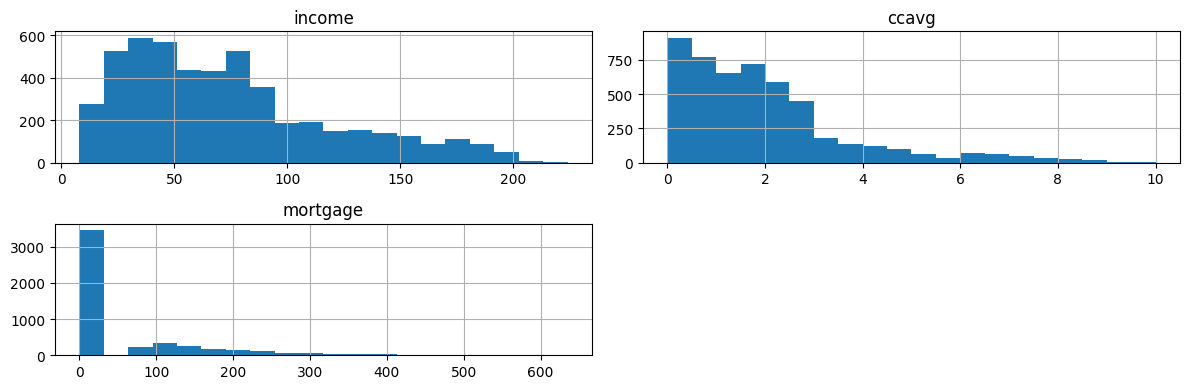

In [18]:
import matplotlib.pyplot as plt

loanData[['income', 'ccavg', 'mortgage']].hist(
    bins=20,
    figsize=(12, 4)
)

plt.tight_layout()
plt.show()

### Initial Observations

- `experience` contains negative values, which appear unusual and
  require further investigation.
- `income`, `ccavg`, and `mortgage` show right-skewed distributions.
- The distributions contain observations concentrated at lower values
  with a smaller number of higher-value observations.

### Implication

The negative `experience` values should be investigated before deciding
whether they should be corrected or removed.

The distributions of `income`, `ccavg`, and `mortgage` may also need
further visualization.

### 6. Categorical Feature Exploration

#### Question
How are the categorical variables distributed?


Understanding the distribution of these variables helps identify
dominant categories, rare categories, and variables that may be
useful for further analysis.

In [19]:
categorical_cols = [
    'family',
    'education',
    'securities_account',
    'cd_account',
    'online',
    'creditcard'
]

for col in categorical_cols:
    print(f"\n{col}")
    print(loanData[col].value_counts())


family
family
1    1472
2    1296
4    1222
3    1010
Name: count, dtype: int64

education
education
1    2096
3    1501
2    1403
Name: count, dtype: int64

securities_account
securities_account
0    4478
1     522
Name: count, dtype: int64

cd_account
cd_account
0    4698
1     302
Name: count, dtype: int64

online
online
1    2984
0    2016
Name: count, dtype: int64

creditcard
creditcard
0    3530
1    1470
Name: count, dtype: int64


### Initial Observations

- The binary variables are not equally distributed across their
  categories.
- `cd_account` has a relatively small number of observations in
  class 1.
- `securities_account` is also concentrated in class 0.
- `family` and `education` contain multiple discrete categories.

### 7.1 Numerical Features vs Target

#### Question
Do numerical features show differences between customers who accepted
the personal loan and those who did not?

This helps identify variables that may be useful predictors and
determines which relationships should be investigated further.

Based on the numerical exploration, `income`, `ccavg`, and `mortgage`
were selected for further visualization because their distributions
show relatively wide ranges and potential skewness.

`experience` is considered separately because negative values require
investigation.

In [20]:
loanData.groupby('personal_loan')[
    ['age', 'experience', 'income', 'ccavg', 'mortgage']
].mean()

,age,experience,income,ccavg,mortgage
personal_loan,,,,,
0,45.367257,20.132301,66.237389,1.729009,51.789381
1,45.066667,19.843750,144.745833,3.905354,100.845833


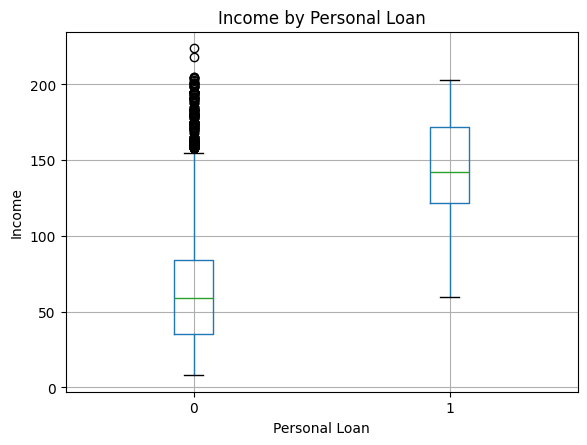

In [21]:
import matplotlib.pyplot as plt

loanData.boxplot(
    column='income',
    by='personal_loan'
)

plt.title('Income by Personal Loan')
plt.suptitle('')
plt.xlabel('Personal Loan')
plt.ylabel('Income')
plt.show()

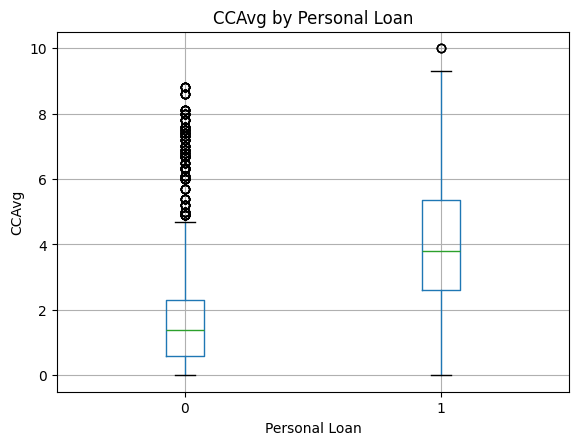

In [22]:
loanData.boxplot(
    column='ccavg',
    by='personal_loan'
)

plt.title('CCAvg by Personal Loan')
plt.suptitle('')
plt.xlabel('Personal Loan')
plt.ylabel('CCAvg')
plt.show()

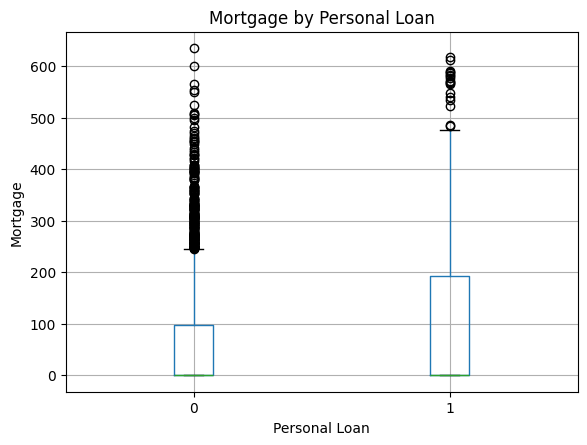

In [23]:
loanData.boxplot(
    column='mortgage',
    by='personal_loan'
)

plt.title('Mortgage by Personal Loan')
plt.suptitle('')
plt.xlabel('Personal Loan')
plt.ylabel('Mortgage')
plt.show()

### Initial Observations

- The distributions of `income`, `ccavg`, and `mortgage` differ between
  customers with and without a personal loan.
- Customers who accepted a personal loan tend to have higher `income` and `ccavg` values than customers who did not.
- `mortgage` also shows differences between the two target groups,
  although both groups contain many observations with zero mortgage.
- These differences suggest that these numerical variables may contain useful information for the classification task.

However, these observations describe group-level differences and do not
by themselves establish predictive importance.
- However, EDA alone does not establish predictive importance.

### 7.2. Categorical Features vs Target

Do loan acceptance rates differ across categories?

In [24]:
categorical_cols = [
    'family',
    'education',
    'securities_account',
    'cd_account',
    'online',
    'creditcard'
]

for col in categorical_cols:
    print(f"\n{col}")
    print(
        loanData.groupby(col)['personal_loan'].mean().mul(100)
    )


family
family
1     7.269022
2     8.179012
3    13.168317
4    10.965630
Name: personal_loan, dtype: float64

education
education
1     4.437023
2    12.972202
3    13.657562
Name: personal_loan, dtype: float64

securities_account
securities_account
0     9.379187
1    11.494253
Name: personal_loan, dtype: float64

cd_account
cd_account
0     7.237122
1    46.357616
Name: personal_loan, dtype: float64

online
online
0    9.375000
1    9.752011
Name: personal_loan, dtype: float64

creditcard
creditcard
0    9.546742
1    9.727891
Name: personal_loan, dtype: float64


### Initial Observations

- Loan acceptance rates vary across some categorical groups.
- `education` and `family` show noticeable differences in observed
  acceptance rates across categories.
- `cd_account` shows a particularly large difference in acceptance
  rates, but the class-1 group contains substantially fewer
  observations.
- `online` and `creditcard` show relatively small differences in
  acceptance rates.

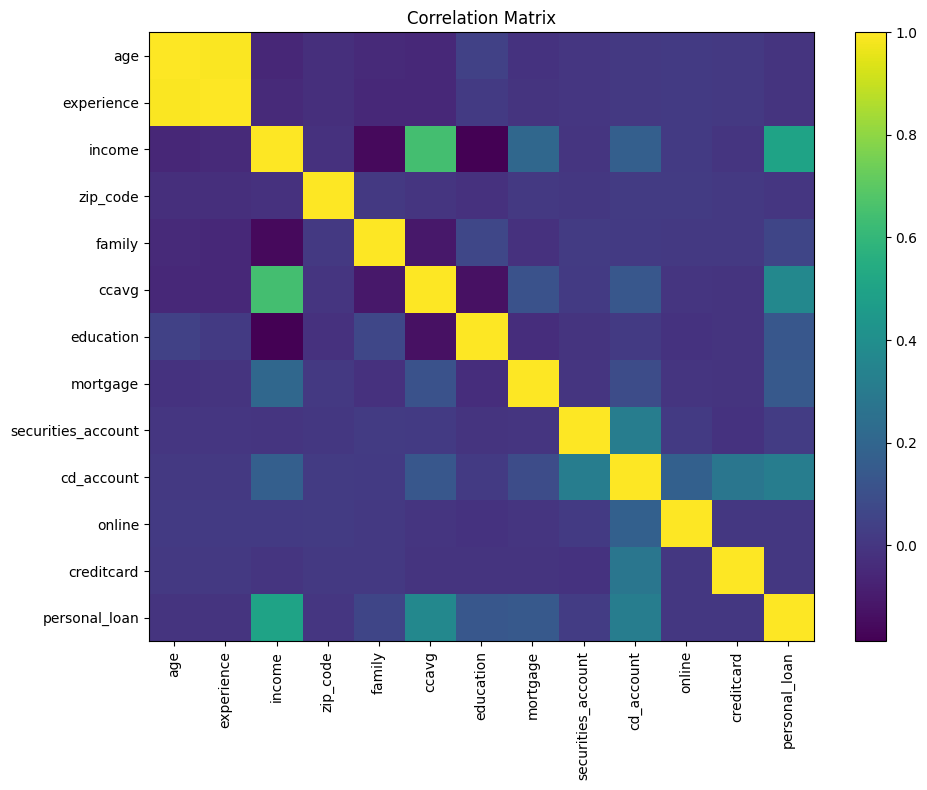

In [25]:
import matplotlib.pyplot as plt

corr_matrix = loanData.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()